<a href="https://colab.research.google.com/github/Kovibordy/ML-2.0/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Задание **2**

Импортируем библиотеки

In [2]:
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

Загружаем данные

In [4]:
df = pd.read_csv('hour.csv')

# Преобразование даты
df['dteday'] = pd.to_datetime(df['dteday'])
df.set_index('dteday', inplace=True)

# Агрегация по дням: суммарное количество аренд
daily = df.resample('D')['cnt'].sum().to_frame()
print("Размер дневного ряда:", daily.shape)
print(daily.head())

Размер дневного ряда: (731, 1)
             cnt
dteday          
2011-01-01   985
2011-01-02   801
2011-01-03  1349
2011-01-04  1562
2011-01-05  1600


Визуализация и декомпозация данных

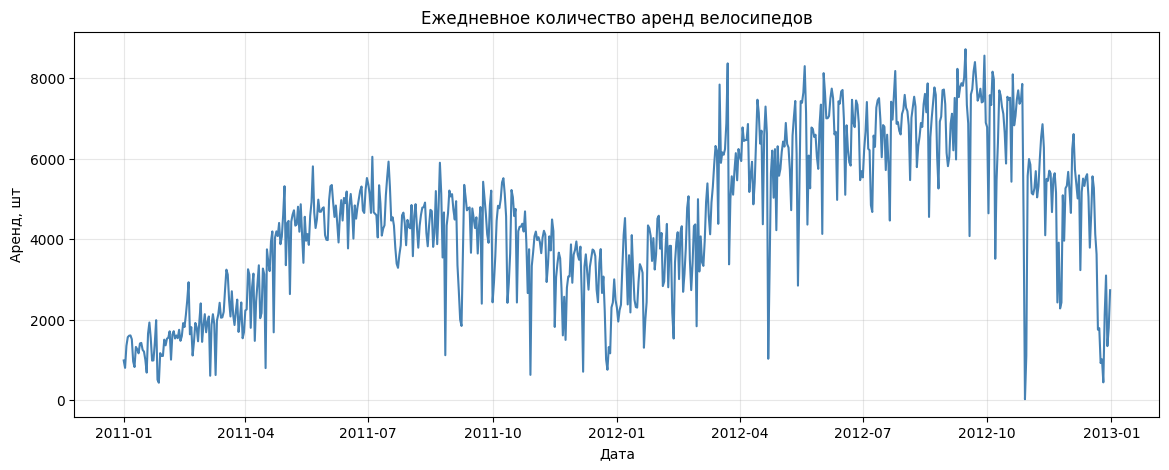

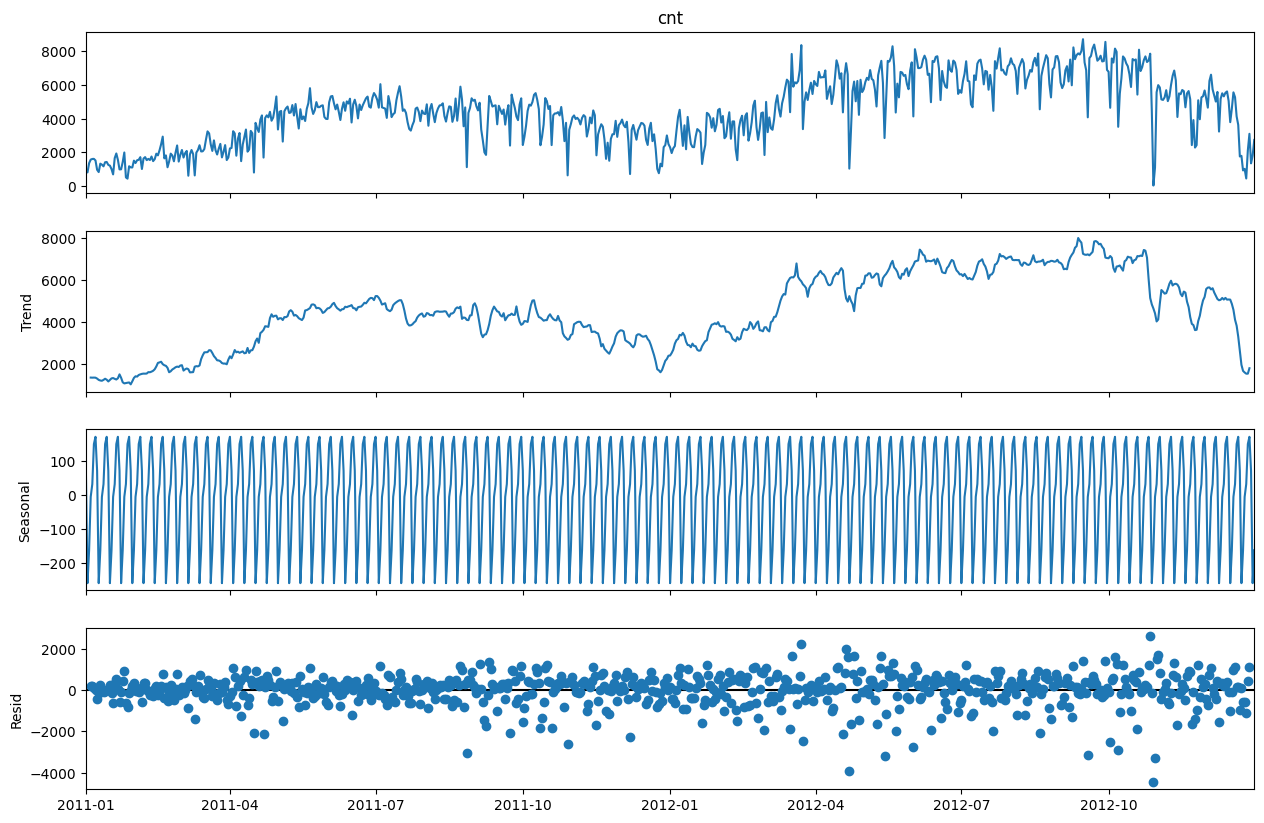

In [5]:
# Исходный ряд
plt.figure(figsize=(14,5))
plt.plot(daily.index, daily['cnt'], color='steelblue')
plt.title('Ежедневное количество аренд велосипедов')
plt.xlabel('Дата'); plt.ylabel('Аренд, шт')
plt.grid(alpha=0.3)
plt.show()

# Декомпозиция (тренд, сезонность, остаток)
decomposition = seasonal_decompose(daily['cnt'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 9)
plt.show()

Делаем train/test

In [6]:
n = len(daily)
train_size = int(n * 0.8)
train = daily.iloc[:train_size]
test  = daily.iloc[train_size:]

print(f"Train: {train.index.min()} — {train.index.max()} ({len(train)} дней)")
print(f"Test : {test.index.min()} — {test.index.max()} ({len(test)} дней)")

Train: 2011-01-01 00:00:00 — 2012-08-06 00:00:00 (584 дней)
Test : 2012-08-07 00:00:00 — 2012-12-31 00:00:00 (147 дней)


Далее делаем ADF-тест

In [7]:
def adf_report(series, name='Ряд'):
    result = adfuller(series.dropna())
    print(f"--- ADF-тест для: {name} ---")
    print(f"ADF statistic: {result[0]:.4f}")
    print(f"p-value      : {result[1]:.4f}")
    print("Критические значения:")
    for k, v in result[4].items():
        print(f"  {k}: {v:.4f}")
    print("Вывод:", "ряд стационарен" if result[1] < 0.05 else "ряд НЕ стационарен")
    print()

adf_report(train['cnt'], 'Исходный train')
adf_report(train['cnt'].diff(), '1-я разность')

--- ADF-тест для: Исходный train ---
ADF statistic: -1.5423
p-value      : 0.5125
Критические значения:
  1%: -3.4418
  5%: -2.8666
  10%: -2.5695
Вывод: ряд НЕ стационарен

--- ADF-тест для: 1-я разность ---
ADF statistic: -10.5417
p-value      : 0.0000
Критические значения:
  1%: -3.4419
  5%: -2.8666
  10%: -2.5695
Вывод: ряд стационарен



ACF и PACF

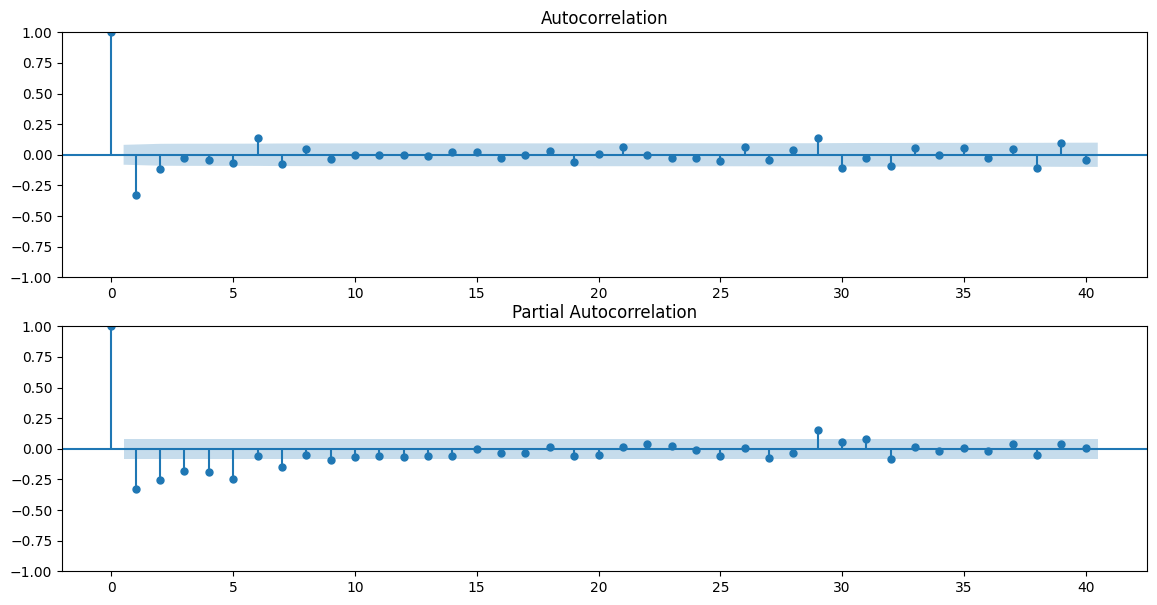

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train['cnt'].diff().dropna(), ax=ax[0], lags=40)
plot_pacf(train['cnt'].diff().dropna(), ax=ax[1], lags=40)
plt.show()

Модель ARIMA

In [9]:
# Автоматический подбор p,d,q
arima_model = auto_arima(
    train['cnt'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,                 # определится тестом
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    error_action='ignore'
)
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9715.391, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9650.502, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9553.328, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9713.454, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9518.984, Time=0.42 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=9519.966, Time=0.46 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=9520.180, Time=0.55 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=9519.199, Time=0.71 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=9614.697, Time=0.13 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.32 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=9520.562, Time=0.13 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 4.066 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  584
M

Обучение ARIMA и прогноз

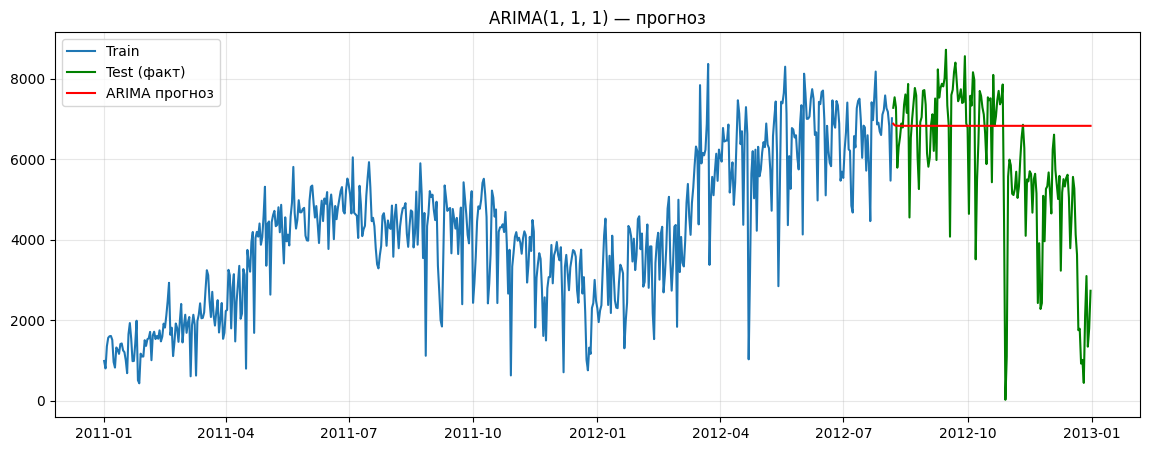

In [10]:
arima_fit = ARIMA(train['cnt'], order=arima_model.order).fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

plt.figure(figsize=(14,5))
plt.plot(train.index, train['cnt'], label='Train')
plt.plot(test.index, test['cnt'], label='Test (факт)', color='green')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA прогноз', color='red')
plt.title(f'ARIMA{arima_model.order} — прогноз')
plt.legend(); plt.grid(alpha=0.3); plt.show()

Метрики ARIMA

In [11]:
def metrics(y_true, y_pred, name='Модель'):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name}: MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
    return mae, rmse, mape

arima_scores = metrics(test['cnt'], arima_forecast, 'ARIMA')

ARIMA: MAE=1514.71  RMSE=2091.37  MAPE=266.16%


Модель SARIMA

In [12]:
# Сезонность недельная (s=7) делаем 7 дней
sarima_model = auto_arima(
    train['cnt'],
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, D=1, m=7,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    seasonal=True,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    error_action='ignore'
)
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=9832.676, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=9621.548, Time=0.55 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=9542.027, Time=0.73 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=9832.528, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=9799.207, Time=0.12 sec
 ARIMA(0,0,1)(1,1,1)[7] intercept   : AIC=9537.675, Time=1.12 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=9628.990, Time=0.41 sec
 ARIMA(0,0,1)(2,1,1)[7] intercept   : AIC=9537.570, Time=1.24 sec
 ARIMA(0,0,1)(2,1,0)[7] intercept   : AIC=9567.469, Time=2.85 sec
 ARIMA(0,0,1)(2,1,2)[7] intercept   : AIC=9538.266, Time=3.27 sec
 ARIMA(0,0,1)(1,1,2)[7] intercept   : AIC=9536.455, Time=3.09 sec
 ARIMA(0,0,1)(0,1,2)[7] intercept   : AIC=9536.352, Time=2.11 sec
 ARIMA(0,0,0)(0,1,2)[7] intercept   : AIC=9610.599, Time=0.87 sec
 ARIMA(1,0,1)(0,1,2)[7] intercept   : AIC=inf, Time=4.09 sec
 ARIMA(0,0,2)(0,1,2)[7] intercept   : 

Обучение SARIMA и прогноз

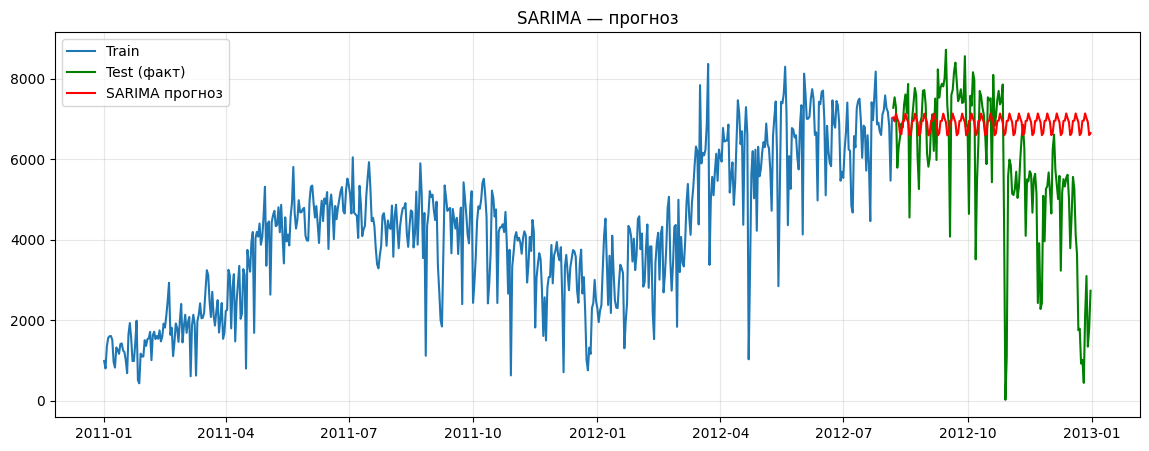

SARIMA: MAE=1498.25  RMSE=2095.15  MAPE=260.63%


In [13]:
sarima_fit = SARIMAX(
    train['cnt'],
    order=sarima_model.order,
    seasonal_order=sarima_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

plt.figure(figsize=(14,5))
plt.plot(train.index, train['cnt'], label='Train')
plt.plot(test.index, test['cnt'], label='Test (факт)', color='green')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA прогноз', color='red')
plt.title('SARIMA — прогноз')
plt.legend(); plt.grid(alpha=0.3); plt.show()

sarima_scores = metrics(test['cnt'], sarima_forecast, 'SARIMA')

Подготовка данных для LSTM

In [14]:
# Нормализация
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(daily[['cnt']].values)

# Разделение по той же границе
train_scaled = scaled[:train_size]
test_scaled  = scaled[train_size:]

WINDOW = 7   # окно 7 дней -> прогноз следующего дня

def make_windows(data, window=WINDOW):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, 0])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, WINDOW)
# Для теста: чтобы прогноз был "по одному" на тестовый день,
# дадим контекст из последних WINDOW значений train + test
full_test = np.concatenate([train_scaled[-WINDOW:], test_scaled], axis=0)
X_test, y_test = make_windows(full_test, WINDOW)

X_train = X_train.reshape(-1, WINDOW, 1)
X_test  = X_test.reshape(-1, WINDOW, 1)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (577, 7, 1) | X_test: (147, 7, 1)


Построение и обучение LSTM

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0658 - val_loss: 0.0484
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0173 - val_loss: 0.0248
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0165 - val_loss: 0.0192
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0146 - val_loss: 0.0151
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0141 - val_loss: 0.0175
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0162 - val_loss: 0.0148
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0147 - val_loss: 0.0164
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0143 - val_loss: 0.0151
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0143 - val_loss: 0.0141
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0135 - val_loss: 0.0134
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0137 - val_loss: 0.0139
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.

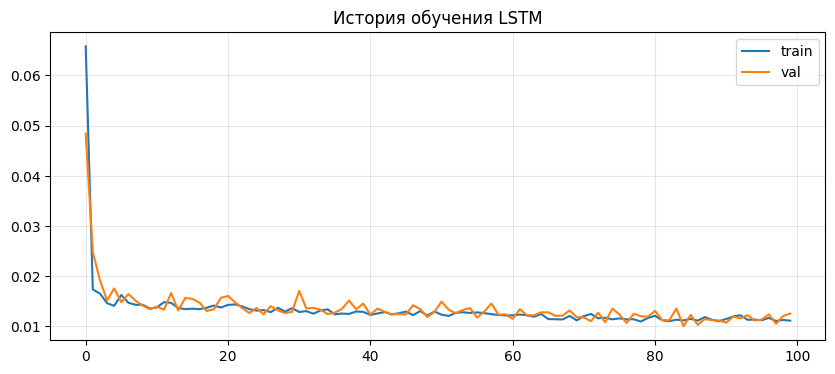

In [15]:
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

early = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=16,
    validation_split=0.1,
    callbacks=[early],
    verbose=1
)

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('История обучения LSTM'); plt.legend(); plt.grid(alpha=0.3); plt.show()

Прогноз LSTM

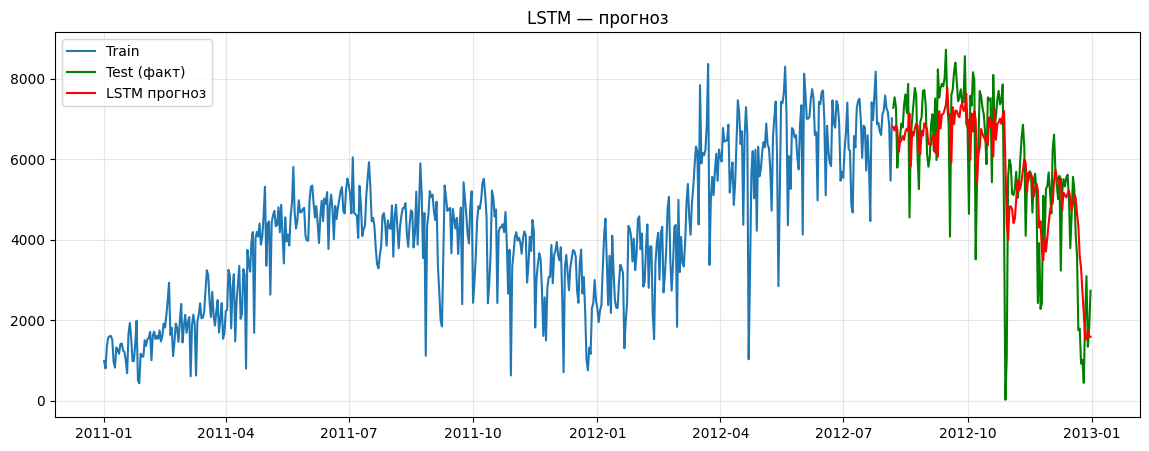

LSTM: MAE=904.02  RMSE=1218.20  MAPE=205.39%


In [16]:
pred_scaled = model.predict(X_test, verbose=0)
# Обратное преобразование
lstm_forecast = scaler.inverse_transform(pred_scaled).ravel()
lstm_forecast = pd.Series(lstm_forecast, index=test.index)

plt.figure(figsize=(14,5))
plt.plot(train.index, train['cnt'], label='Train')
plt.plot(test.index, test['cnt'], label='Test (факт)', color='green')
plt.plot(lstm_forecast.index, lstm_forecast, label='LSTM прогноз', color='red')
plt.title('LSTM — прогноз')
plt.legend(); plt.grid(alpha=0.3); plt.show()

lstm_scores = metrics(test['cnt'], lstm_forecast, 'LSTM')

Сравнение всех моделей

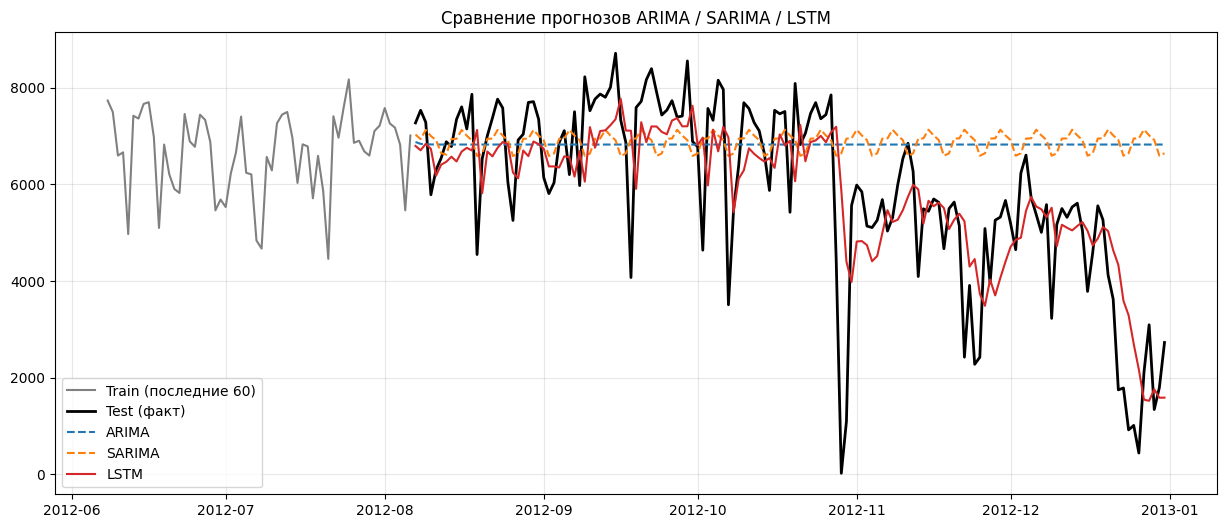

Модель         MAE        RMSE    MAPE, %
 ARIMA 1514.709418 2091.374506 266.157004
SARIMA 1498.246641 2095.145873 260.630485
  LSTM  904.023621 1218.198055 205.393805


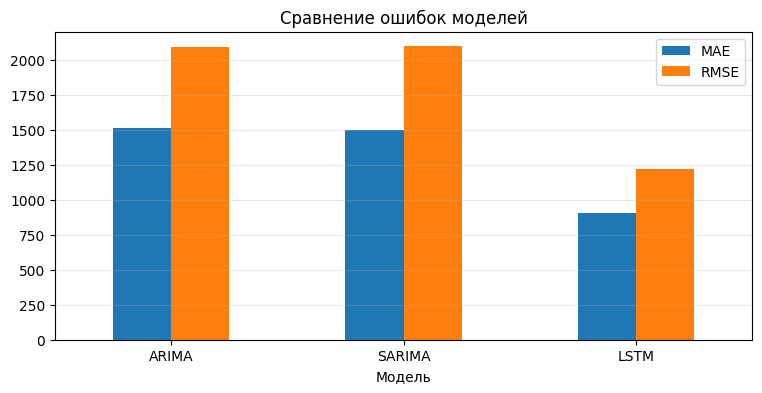

In [17]:
# График сравнения
plt.figure(figsize=(15,6))
plt.plot(train.index[-60:], train['cnt'].iloc[-60:], label='Train (последние 60)', color='gray')
plt.plot(test.index, test['cnt'], label='Test (факт)', color='black', linewidth=2)
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA', color='tab:blue', linestyle='--')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA', color='tab:orange', linestyle='--')
plt.plot(lstm_forecast.index, lstm_forecast, label='LSTM', color='tab:red')
plt.title('Сравнение прогнозов ARIMA / SARIMA / LSTM')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Таблица метрик
results = pd.DataFrame({
    'Модель': ['ARIMA', 'SARIMA', 'LSTM'],
    'MAE'  : [arima_scores[0],  sarima_scores[0],  lstm_scores[0]],
    'RMSE' : [arima_scores[1],  sarima_scores[1],  lstm_scores[1]],
    'MAPE, %': [arima_scores[2], sarima_scores[2], lstm_scores[2]],
})
print(results.to_string(index=False))

# Столбчатая диаграмма сравнения RMSE
results.set_index('Модель')[['MAE','RMSE']].plot(kind='bar', figsize=(9,4), rot=0)
plt.title('Сравнение ошибок моделей')
plt.grid(axis='y', alpha=0.3)
plt.show()